# Remove background

## Sources:
- [Background Subtraction – OpenCV 3.4 with python 3 Tutorial 32](https://pysource.com/2018/05/17/background-subtraction-opencv-3-4-with-python-3-tutorial-32/)
- [Background Removal Tutorial using OpenCV - Python | Replace Background with Video - WITH CODE](https://www.youtube.com/watch?v=tKA_Ht4P1Gw&t=398s)

## Import modules

In [1]:
# import internal modules
# from typing import List, Set, Dict, TypedDict, Tuple, Optional, Union
from pathlib import Path
from datetime import date


# import 3rd-party modules
import cv2
import numpy as np

# # import local modules
from core.utils.renderer.resizer import resize_with_pad, resize_with_crop
from core.utils.project_manager import Project

OpenCV bindings requires "numpy" package.
Install it via command:
    pip install numpy


ImportError: 

IMPORTANT: PLEASE READ THIS FOR ADVICE ON HOW TO SOLVE THIS ISSUE!

Importing the numpy C-extensions failed. This error can happen for
many reasons, often due to issues with your setup or how NumPy was
installed.

We have compiled some common reasons and troubleshooting tips at:

    https://numpy.org/devdocs/user/troubleshooting-importerror.html

Please note and check the following:

  * The Python version is: Python3.9 from "/Users/derrickvanfrausum/anaconda3/envs/cv/bin/python"
  * The NumPy version is: "1.20.3"

and make sure that they are the versions you expect.
Please carefully study the documentation linked above for further help.

Original error was: dlopen(/Users/derrickvanfrausum/anaconda3/envs/cv/lib/python3.9/site-packages/numpy/core/_multiarray_umath.cpython-39-darwin.so, 0x0002): Library not loaded: @rpath/libcblas.3.dylib
  Referenced from: <836827F9-FEC6-3EFF-A4A1-2DA567C3BA2F> /Users/derrickvanfrausum/anaconda3/envs/cv/lib/python3.9/site-packages/numpy/

number of frames = 1045.0
fps = 30.0
video width = 1920
video height = 1080


/var/folders/bc/pp_vy12j36gdx8lc7csstvqh0000gn/T/ipykernel_8754/3883425211.py:76: RuntimeWarning: overflow encountered in ulong_scalars
  white_pixel_sum_distance = np.abs(white_pixels_sum - previous_white_pixel_sum)


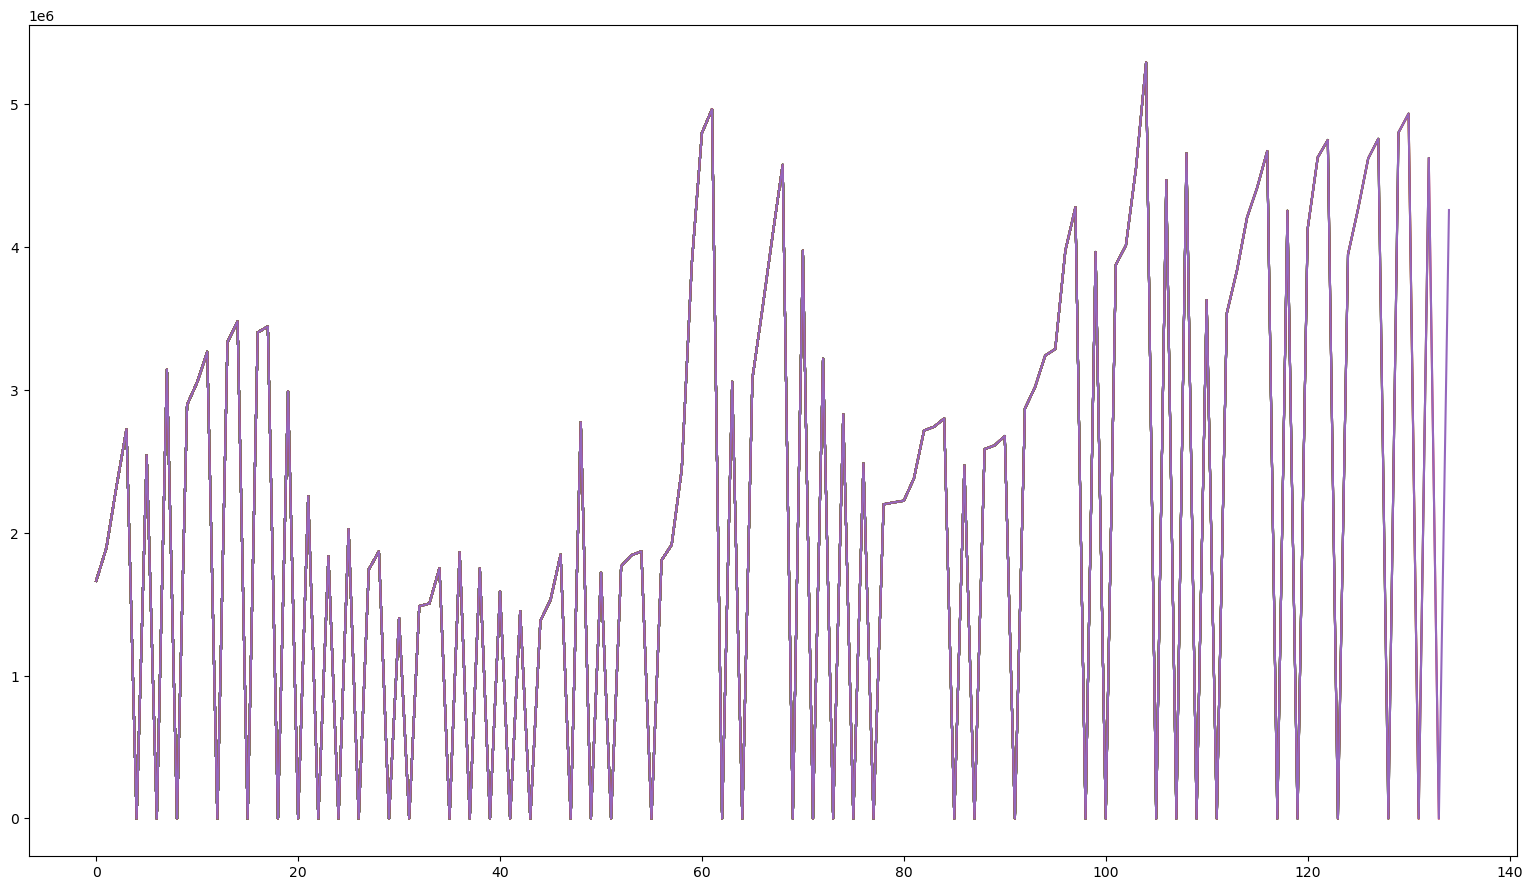

In [110]:
# # get current date
# today = date.today().strftime("%Y%m%d")

# set input & output video path
video_path = Path("/Users/derrickvanfrausum/DD_AI/bosa-skiing/streamlit_data/merge.mp4")
# out_path = f"assets/images/bg_remover/{video_path.stem}_{today}.mp4"

# Initialize video stream
video_cap = cv2.VideoCapture(str(video_path))

# set window names
WINDOW_NAME_DIFF = "diff"
WINDOW_NAME_VIDEO = "video"

# get video parameters
video_n_frames = video_cap.get(cv2.CAP_PROP_FRAME_COUNT)
video_fps = video_cap.get(cv2.CAP_PROP_FPS)
video_width = int(video_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
video_height = int(video_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"number of frames = {video_n_frames}")
print(f"fps = {video_fps}")
print(f"video width = {video_width}")
print(f"video height = {video_height}")

# # set frame position to a given index
# seconds = 3 * 60
# start_frame = int(seconds*video_fps)
# end_frame = int(5*60*video_fps)
# video_cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame) # at 17 seconds

# # read frame at this index
# _, ref_frame = video_cap.read()
# # ref_img_height, ref_img_width, ref_img_channel = ref_frame.shape
# ref_gray = cv2.cvtColor(ref_frame, cv2.COLOR_BGR2GRAY)
# ref_gray = cv2.GaussianBlur(ref_gray, (5, 5), 0)

# # set frame position back to the start
# video_cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

subtractor = cv2.createBackgroundSubtractorMOG2(history=20, varThreshold=80, detectShadows=True)

white_pixels = []
previous_white_pixel_sum = 0

# Make a random plot...
fig = plt.figure(figsize=(19.2, 10.8))
fig.add_subplot(111)
# ax = plt.gca()
# ax.set_ylim([0, 2000000])

# while accessing stream 
# while video_cap.isOpened():
# for i in range(end_frame - start_frame):

# while True:
for i in range(int(video_n_frames)):
    # read video stream
    ret, frame = video_cap.read()

    # break out of loop if no more frame
    if not ret:
        print("Ignoring empty camera frame.")
        break

    mask = subtractor.apply(frame)

    # allow subtractor to remove bg with an history of 20 frames
    if i < 20:
        # continue
        white_pixels_sum = -1

    else:

        white_pixels_sum = np.sum(mask)
        white_pixel_sum_distance = np.abs(white_pixels_sum - previous_white_pixel_sum)

        if white_pixel_sum_distance > 60000000:
            white_pixels_sum = -1

    white_pixels.append(white_pixels_sum)

    previous_white_pixel_sum = white_pixels_sum

    # cv2.rectangle(mask, (x, y), (x2, y2), (255, 0, 0), 3)
    frame = cv2.putText(frame, str(white_pixels_sum), (10, 100), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA, False)

    plt.plot(white_pixels[20:])

    # If we haven't already shown or saved the plot, then we need to
    # draw the figure first...
    fig.canvas.draw()

    # Now we can save it to a numpy array.
    data = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    data = data.reshape(fig.canvas.get_width_height()[::-1] + (3,))

    # gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    # gray_frame = cv2.GaussianBlur(gray_frame, (5, 5), 0)

    # difference = cv2.absdiff(ref_gray, gray_frame)
    # _, difference = cv2.threshold(difference, 25, 255, cv2.THRESH_BINARY)

    #  # create a mask
    # diff1 = cv2.subtract(frame,ref_frame)
    # diff2=cv2.subtract(ref_img,img)
    # diff = diff1+diff2
    # diff[abs(diff)<13.0]=0
    # gray = cv2.cvtColor(diff.astype(np.uint8), cv2.COLOR_BGR2GRAY)
    # gray[np.abs(gray) < 10] = 0
    # fgmask = gray.astype(np.uint8)
    # fgmask[fgmask>0]=255
    # #invert the mask
    # fgmask_inv = cv2.bitwise_not(fgmask)
    # #use the masks to extract the relevant parts from FG and BG
    # fgimg = cv2.bitwise_and(img,img,mask = fgmask)
    # bgimg = cv2.bitwise_and(bg,bg,mask = fgmask_inv)
    # #combine both the BG and the FG images
    # dst = cv2.add(bgimg,fgimg)
    # cv2.imshow('Background Removal',dst)

    # show to screen
    # cv2.imshow(WINDOW_NAME_DIFF, cv2.hconcat([mask,data]))
    mask = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    cv2.imshow(WINDOW_NAME_DIFF, cv2.hconcat([mask,data]))
    cv2.imshow(WINDOW_NAME_VIDEO, frame)

    # wait for a key 
    # 0xFF to check what key we pressed on the keyboard
    key = cv2.waitKey(10) & 0xFF

    # break out of the stream loop if esc is pressed
    if key == 27 or key == ord('q'):        
        break


# quit windows
cv2.destroyAllWindows()
cv2.waitKey(1) # workaround to effectively close window on mac

# release video stream
video_cap.release()

In [107]:
plt.close("all")

In [ ]:
# from scipy.signal import savgol_filter

In [111]:
window_width = 200
cumsum_vec = np.cumsum(np.insert(white_pixels, 0, 0)) 
ma_vec = (cumsum_vec[window_width:] - cumsum_vec[:-window_width]) / window_width

In [113]:
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth

In [95]:
white_pixels

[8659,
 8659,
 8659,
 8659,
 8659,
 8659,
 8659,
 8659,
 8659,
 8659,
 8659,
 8659,
 8659,
 8659,
 8659,
 13874,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 15788,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,
 21777,

In [91]:
np.argmax(white_pixels[1:])

440

In [93]:
white_pixels[430:450]

[3818,
 -1,
 0,
 0,
 0,
 0,
 0,
 254,
 -1,
 0,
 0,
 5708356,
 -1,
 127,
 -1,
 0,
 0,
 15261,
 -1,
 255]

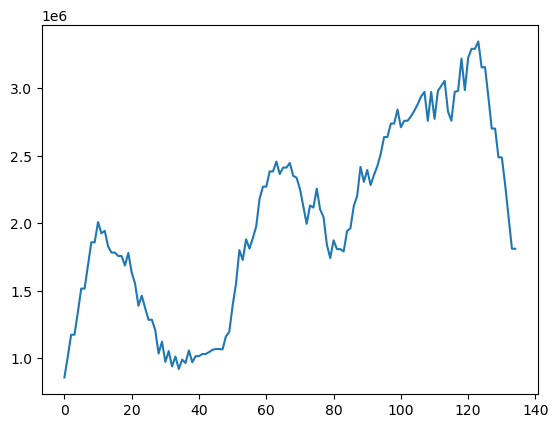

: 

In [121]:
# from matplotlib import pyplot as plt

plt.plot(smooth(white_pixels[20:], 20))
# convert plot to image 

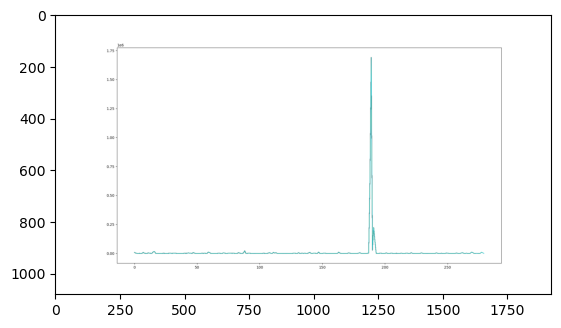

In [29]:
plt.imshow(data)

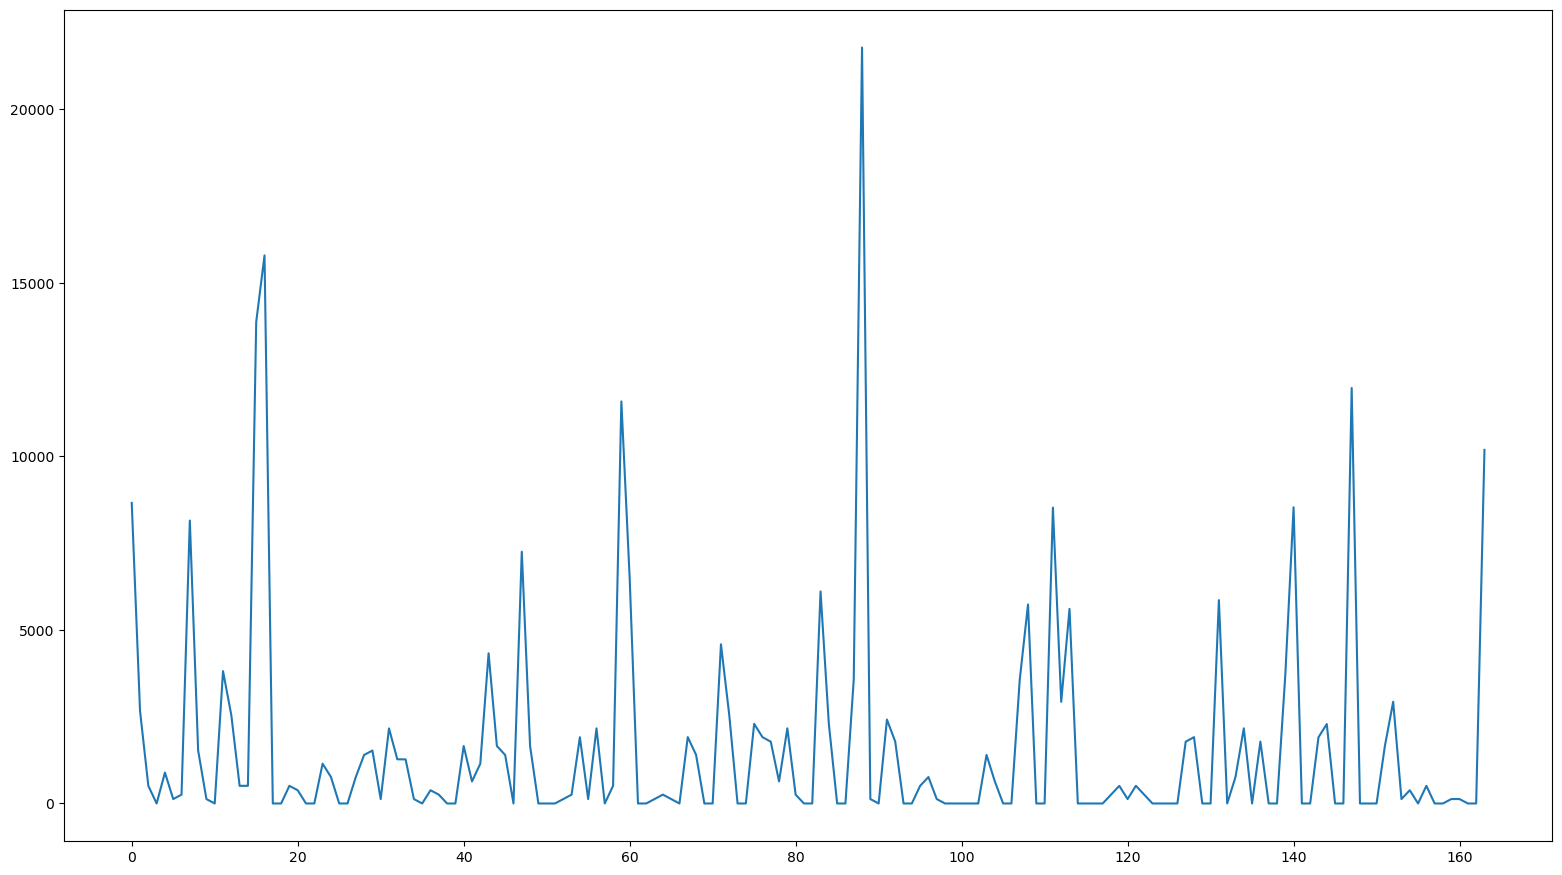

In [20]:
# Make a random plot...
fig = plt.figure(figsize=(19.2, 10.8))
fig.add_subplot(111)
plt.plot(white_pixels[20:])

# If we haven't already shown or saved the plot, then we need to
# draw the figure first...
fig.canvas.draw()

# Now we can save it to a numpy array.
data = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
data = data.reshape(fig.canvas.get_width_height()[::-1] + (3,))

In [21]:
data.shape

(1080, 1920, 3)

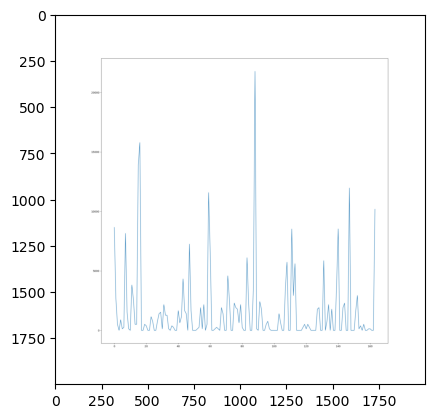

In [17]:
plt.imshow(data)
plt.show()

In [ ]:
# get current date
today = date.today().strftime("%Y%m%d")

# set video path
filepath = Path("/Users/derrickvanfrausum/BeCode_AI/git-repos/coding-art/core/assets/images/db/P1899019.mov")
out_path = f"assets/images/bg_remover/{filepath.stem}_{today}.mp4"

codec = "H264"

# initialize video stream
cap = cv2.VideoCapture(str(filepath))

# set frame position to the index
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

_, first_frame = cap.read()
ref_img_height, ref_img_width, ref_img_channel = first_frame.shape

# create a videoWriter object
fourcc = cv2.VideoWriter_fourcc(*codec)
out_video = cv2.VideoWriter(filename=out_path, fourcc=fourcc, fps=fps, frameSize=(ref_img_width, ref_img_height))

# create empty list of frames
frames = []
frame_nb = 0

while True:

    # read frame
    ret, frame = cap.read()

    if not ret:
        break

    # append frame to list of frames
    frames.append(frame)

    if frame_nb%frame_factor == 0:
        # compute average of frames
        # bg_frame = np.mean(frames, axis=0).astype(dtype=np.uint8)
        out_frame = np.median(frames, axis=0).astype(dtype=np.uint8)

        # write output frame
        out_video.write(out_frame)

        frames = []

    frame_nb += 1

# release video stream & video rendering
cap.release()
out_video.release()

## Blend video with background removed, with another video

In [2]:
# get current date
today = date.today().strftime("%Y%m%d")

# set input & output video path
# video_path = Path("assets/images/gagu/gagu_for_shadow.mp4")
video_path = Path("/Users/derrickvanfrausum/Desktop/230_PANA/P2300219.MP4")
video_path_2 = Path("/Users/derrickvanfrausum/Desktop/230_PANA/P2300219.MP4")
out_path = f"assets/images/bg_remover/{video_path.stem}_{today}_delay_only_mask_no_blur.mp4"

# Initialize video stream
video_cap = cv2.VideoCapture(str(video_path))
video_cap_2 = cv2.VideoCapture(str(video_path_2))

# set window names
# WINDOW_NAME_DIFF = "diff"
WINDOW_NAME_VIDEO = "video"

# get video parameters
video_n_frames = video_cap.get(cv2.CAP_PROP_FRAME_COUNT)
video_fps = video_cap.get(cv2.CAP_PROP_FPS)
video_width = int(video_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
video_height = int(video_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"number of frames = {video_n_frames}")
print(f"fps = {video_fps}")
print(f"video width = {video_width}")
print(f"video height = {video_height}")

# set codec for output video
codec = "H264"

rotate = False
resize = False

# set output shape
# out_height, out_width, out_channel = 1920, 1080, 3
# out_height, out_width, out_channel = video_height, video_width*2, 3
out_height, out_width, out_channel = video_height, video_width, 3

# create a videoWriter object
fourcc = cv2.VideoWriter_fourcc(*codec)
out_video = cv2.VideoWriter(filename=str(out_path), fourcc=fourcc, fps=video_fps, frameSize=(out_width, out_height))

# set frame position to a given index
video_cap.set(cv2.CAP_PROP_POS_FRAMES, int(0*video_fps)) # at x seconds
video_cap_2.set(cv2.CAP_PROP_POS_FRAMES, int(1*video_fps)) # at x seconds

subtractor = cv2.createBackgroundSubtractorMOG2(history=20, varThreshold=100, detectShadows=True)

# while accessing stream 
while True:

    # read video stream
    ret, frame = video_cap.read()
    ret_2, frame_2 = video_cap_2.read()

    # if only one video returns a frame, replace the empty frame from the other video by a black frame
    if (not ret) and (ret_2):
        frame = np.zeros((video_height, video_width, 3), dtype=np.uint8)
    elif (ret) and (not ret_2):
        frame_2 = np.zeros((video_height, video_width, 3), dtype=np.uint8)

    # break out of loop if no more frame
    elif (not ret) and (not ret_2):
        print("Ignoring empty camera frame.")
        break

    mask = subtractor.apply(frame)
    # mask = cv2.GaussianBlur(mask, (15, 15), 0)
    # mask = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    mask = cv2.applyColorMap(mask, cv2.COLORMAP_BONE)

    # # stack horizontally mask frame and end result frame
    # out_frame = cv2.hconcat([mask, cv2.add(frame_2, mask)])
    out_frame = mask

    # rotate & resize frame if asked
    if rotate:
        out_frame = np.rot90(out_frame, -1)
    
    if resize:
        out_frame = resize_with_crop(out_frame, ref_img_shape=(out_height, out_width, out_channel))

    # write output frame
    out_video.write(out_frame)

    # show to screen
    # cv2.imshow(WINDOW_NAME_DIFF, mask)
    cv2.imshow(WINDOW_NAME_VIDEO, out_frame)

    # wait for a key 
    # 0xFF to check what key we pressed on the keyboard
    key = cv2.waitKey(10) & 0xFF

    # break out of the stream loop if esc is pressed
    if key == 27 or key == ord('q'):        
        break


# quit windows
cv2.destroyAllWindows()
cv2.waitKey(1) # workaround to effectively close window on mac

# release video stream & video rendering
video_cap.release()
video_cap_2.release()
out_video.release()


number of frames = 60.0
fps = 25.0
video width = 3840
video height = 2160


OpenCV: FFMPEG: tag 0x34363248/'H264' is not supported with codec id 27 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x31637661/'avc1'


Ignoring empty camera frame.


### add blend to leave a trace

In [12]:
# get current date
today = date.today().strftime("%Y%m%d")

# for hue in np.linspace(20,24, 2, dtype=np.uint8):
# for hue in [33]:
for i in range(1):

    # set input & output video path
    # video_path = Path("assets/images/gagu/gagu_for_shadow.mp4")
    video_path = Path("/Users/derrickvanfrausum/Downloads/Comp 1_1_processed.mp4")
    video_path_2 = Path("/Users/derrickvanfrausum/Downloads/Comp 1_1_processed.mp4")

    # Initialize video stream
    video_cap = cv2.VideoCapture(str(video_path))
    video_cap_2 = cv2.VideoCapture(str(video_path_2))

    # set window names
    # WINDOW_NAME_DIFF = "diff"
    WINDOW_NAME_VIDEO = "video"

    # get video parameters
    video_n_frames = video_cap.get(cv2.CAP_PROP_FRAME_COUNT)
    video_fps = video_cap.get(cv2.CAP_PROP_FPS)
    video_width = int(video_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    video_height = int(video_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"number of frames = {video_n_frames}")
    print(f"fps = {video_fps}")
    print(f"video width = {video_width}")
    print(f"video height = {video_height}")

    # set codec for output video
    codec = "H264"

    # set colormap
    colormap = cv2.COLORMAP_BONE
    # colormap = "random_ocean_inferno"
    # colormaps = [
    #     cv2.COLORMAP_OCEAN,
    #     cv2.COLORMAP_INFERNO,
    #     # cv2.COLORMAP_DEEPGREEN
    #     ]

    blur = 15

    masks_window = []
    NB_MASKS = int(0.20*video_fps) # number of masks for 0.5 second int(video_n_frames)
    # NB_MASKS = 5
    # get range to set images blending alpha at each step
    alpha_range = np.linspace(0.1, 0.7, NB_MASKS) # np.linspace(0.1, 0.7, NB_MASKS)
    # masks = np.zeros((video_height, video_width, 3), dtype=np.uint8)

    rotate = False
    resize = False

    # set output shape
    # out_height, out_width, out_channel = 1920, 1080, 3
    # out_height, out_width, out_channel = video_height, video_width*2, 3
    out_height, out_width, out_channel = video_height, video_width, 3

    # out_path = f"assets/images/bg_remover/{video_path.stem}_{today}_masks_{colormap}_{hue}.mp4"
    out_path = f"assets/images/bg_remover/{video_path.stem}_{today}_masks_{colormap}_{i}_{blur}_{NB_MASKS}_mask.mp4"

    # create a videoWriter object
    fourcc = cv2.VideoWriter_fourcc(*codec)
    out_video = cv2.VideoWriter(filename=str(out_path), fourcc=fourcc, fps=video_fps, frameSize=(out_width, out_height))

    # # set frame position to a given index
    # video_cap.set(cv2.CAP_PROP_POS_FRAMES, int(1*video_fps)) # at x seconds

    subtractor = cv2.createBackgroundSubtractorMOG2(history=20, varThreshold=100, detectShadows=True)

    frame_nb = 0
    # while accessing stream 
    while True:

        # read video stream
        ret, frame = video_cap.read()
        ret_2, frame_2 = video_cap_2.read()

        # if only one video returns a frame, replace the empty frame from the other video by a black frame
        if (not ret) and (ret_2):
            frame = np.zeros((video_height, video_width, 3), dtype=np.uint8)
        elif (ret) and (not ret_2):
            frame_2 = np.zeros((video_height, video_width, 3), dtype=np.uint8)

        # break out of loop if no more frame
        elif (not ret) and (not ret_2):
            print("Ignoring empty camera frame.")
            break

        # if frame_nb % (video_fps//4) == 0:
        mask = subtractor.apply(frame)
        mask = cv2.GaussianBlur(mask, (blur, blur), 0) # (mask, (15, 15), 0)
        mask = cv2.add(frame, frame, mask=mask)
        # mask = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
        mask = cv2.applyColorMap(mask, colormap)//2
        # mask = cv2.applyColorMap(mask, colormaps[np.random.randint(0,len(colormaps))])//2

        # mask = cv2.cvtColor(mask, cv2.COLOR_BGR2HSV)
        # mask[:,:,0] = hue
        # mask = cv2.cvtColor(mask, cv2.COLOR_HSV2BGR)

        masks_window.append(mask)
        if len(masks_window) > NB_MASKS:
            masks_window = masks_window[1:]
            
        masks = masks_window[0]
        # blend image at each step
        for i in range(len(masks_window)):

            # blend image
            alpha = alpha_range[i]
            # beta = 1 - alpha
            beta = 1
            masks = cv2.addWeighted(masks_window[i],alpha, masks, beta, 0)
            # masks = cv2.add(masks_window[i], masks)
        # masks -= 50

        # out_frame = cv2.hconcat([mask, cv2.add(frame_2, mask)])
        # out_frame = cv2.hconcat([masks, cv2.add(frame_2, masks)])
        out_frame = cv2.add(frame_2, masks)
        # out_frame = masks
        # out_frame = masks


        # rotate & resize frame if asked
        if rotate:
            out_frame = np.rot90(out_frame, -1)
        
        if resize:
            out_frame = resize_with_crop(out_frame, ref_img_shape=(out_height, out_width, out_channel))

        # write output frame
        out_video.write(out_frame)

        # show to screen
        # cv2.imshow(WINDOW_NAME_DIFF, mask)
        cv2.imshow(WINDOW_NAME_VIDEO, out_frame)

        # wait for a key 
        # 0xFF to check what key we pressed on the keyboard
        key = cv2.waitKey(10) & 0xFF

        # break out of the stream loop if esc is pressed
        if key == 27 or key == ord('q'):        
            break

        frame_nb += 1


    # quit windows
    cv2.destroyAllWindows()
    cv2.waitKey(1) # workaround to effectively close window on mac

    # release video stream & video rendering
    video_cap.release()
    video_cap_2.release()
    out_video.release()


number of frames = 1000.0
fps = 25.0
video width = 1080
video height = 1920


OpenCV: FFMPEG: tag 0x34363248/'H264' is not supported with codec id 27 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x31637661/'avc1'


Ignoring empty camera frame.


: 

In [13]:
# quit windows
cv2.destroyAllWindows()
cv2.waitKey(1) # workaround to effectively close window on mac

# release video stream & video rendering
video_cap.release()
video_cap_2.release()
out_video.release()

In [21]:
frame_nb % (video_fps)

0.0

## Make a grid out of the results

In [3]:
videos = list(Path("assets/images/bg_remover/gagu_trace").glob("*.mp4"))
videos

[PosixPath('assets/images/bg_remover/gagu_trace/gagu_original_20220504_masks_15.mp4'),
 PosixPath('assets/images/bg_remover/gagu_trace/gagu_original_20220504_masks_1.mp4'),
 PosixPath('assets/images/bg_remover/gagu_trace/gagu_original_20220504_masks_0.mp4'),
 PosixPath('assets/images/bg_remover/gagu_trace/gagu_original_20220504_masks_14.mp4'),
 PosixPath('assets/images/bg_remover/gagu_trace/gagu_original_20220504_masks_16.mp4'),
 PosixPath('assets/images/bg_remover/gagu_trace/gagu_original_20220504_masks_2.mp4'),
 PosixPath('assets/images/bg_remover/gagu_trace/gagu_original_20220504_masks_3.mp4'),
 PosixPath('assets/images/bg_remover/gagu_trace/gagu_original_20220504_masks_17.mp4'),
 PosixPath('assets/images/bg_remover/gagu_trace/gagu_original_20220504_masks_13.mp4'),
 PosixPath('assets/images/bg_remover/gagu_trace/gagu_original_20220504_masks_7.mp4'),
 PosixPath('assets/images/bg_remover/gagu_trace/gagu_original_20220504_masks_6.mp4'),
 PosixPath('assets/images/bg_remover/gagu_trace/g

In [8]:
# get current date
today = date.today().strftime("%Y%m%d")

out_path = f"assets/images/bg_remover/gagu_original_{today}_trace_grid.mp4"

# set codec for output video
codec = "H264"

# rotate = False
# resize = False

# set output shape
out_height, out_width, out_channel = 1920, 1080, 3
# out_height, out_width, out_channel = video_height, video_width*2, 3
# out_height, out_width, out_channel = video_height, video_width, 3

video_fps = 30
# create a videoWriter object
fourcc = cv2.VideoWriter_fourcc(*codec)
out_video = cv2.VideoWriter(filename=str(out_path), fourcc=fourcc, fps=video_fps, frameSize=(out_width, out_height))

video_caps = []
video_lengths = []
for video_path in videos:

    # Initialize video streams
    video_cap = cv2.VideoCapture(str(video_path))
    video_caps.append(video_cap)

    # get video length
    video_n_frames = video_cap.get(cv2.CAP_PROP_FRAME_COUNT)
    video_lengths.append(video_n_frames)

# get number of videos
nb_videos = len(videos)

# get max video length
max_video_length = int(max(video_lengths))

# set subplots grid
len_rows: int = 5
len_cols: int = nb_videos//len_rows

# set window names
# WINDOW_NAME_DIFF = "diff"
WINDOW_NAME_VIDEO = "video"

    # # set frame position to a given index
    # video_cap.set(cv2.CAP_PROP_POS_FRAMES, int(1*video_fps)) # at x seconds

# while accessing stream 
for _ in range(max_video_length):

    frames = []

    # read video streams
    for video_cap in video_caps:
        ret, frame = video_cap.read()

        # replace empty frame by a black one
        if not ret:
            frame = np.zeros((video_height, video_width, 3), dtype=np.uint8)

        frame = resize_with_crop(frame, ref_img_shape=(out_height//len_rows, out_width//len_cols, out_channel))
        
        frames.append(frame)

        
    out_frame = cv2.vconcat([cv2.hconcat(frames[i:i+len_cols]) for i in range(0, nb_videos, len_cols)])

    # # rotate & resize frame if asked
    # if rotate:
    #     out_frame = np.rot90(out_frame, -1)
    
    # if resize:
    #     out_frame = resize_with_crop(out_frame, ref_img_shape=(out_height, out_width, out_channel))

    # write output frame
    out_video.write(out_frame)

    # show to screen
    # cv2.imshow(WINDOW_NAME_DIFF, mask)
    cv2.imshow(WINDOW_NAME_VIDEO, out_frame)

    # wait for a key 
    # 0xFF to check what key we pressed on the keyboard
    key = cv2.waitKey(10) & 0xFF

    # break out of the stream loop if esc is pressed
    if key == 27 or key == ord('q'):        
        break


# quit windows
cv2.destroyAllWindows()
cv2.waitKey(1) # workaround to effectively close window on mac

# release video stream & video rendering
for video_cap in video_caps:
    video_cap.release()
out_video.release()


In [28]:
len([frames[i:i+len_cols] for i in range(0, nb_videos, len_cols)])

5

In [33]:
for row_nb in range(0, nb_videos, len_cols):
    print(row_nb, row_nb+len_cols)
# [i//LEN_ROWS,i - LEN_COLS*(i//LEN_COLS)

0 4
4 8
8 12
12 16
16 20


In [6]:
import cv2
import numpy as np

In [7]:
def lucas_kanade(video_path):
    """
    """
    
    # load video
    cap = cv2.VideoCapture(video_path)
    
    # set parameters for ShiTomasi corner detection
    feature_params = dict(maxCorners=100, qualityLevel=0.3, minDistance=7, blockSize=7)
    
    # set parameters for Lucas Kanade optical flow
    lk_params = dict(
        winSize=(15,15),
        maxLevel=2,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
    )
    
    # create random colors
    color = np.random.randint(0,255, (100, 3))
    
    # take first frame and find corners in it
    ret, old_frame = cap.read()
    old_frame_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
    p0 = cv2.goodFeaturesToTrack(old_frame_gray, mask=None, **feature_params)
    
    # create mask image for drawing purposes
    mask = np.zeros_like(old_frame)
    
    while True:
        # read new frame
        ret, frame = cap.read()
        
        if not ret:
            break
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # compute optical flow
        p1, st, err = cv2.calcOpticalFlowPyrLK(
            old_frame, frame_gray, p0, None, **lk_params
        )
        
        # select good points
        good_new = p1[st == 1]
        good_old = p0[st == 1]
        
        # draw tracks
        for i, (new, old) in enumerate(zip(good_new, good_old)):
            a, b = new.ravel()
            c, d = old.ravel()
            mask = cv2.line(mask, (a,b), (c,d), color[i].tolist(), 2)
            frame = cv2.circle(frame, (a,b), 5, color[i].tolist(), -1)
        
        # display demo
        img = cv2.add(frame, mask)
        cv2.imshow("frame", img)
        k = cv2.waitKey(25) & 0xFF
        if k == 27:
            break
            
        # update previous frame & previous points
        old_gray = frame_gray.copy()
        p0 = good_new.reshape(-1, 1, 2)

In [9]:
path = "/Users/derrickvanfrausum/DD_AI/bosa-skiing/data/concat_SnowValleyPt1_GoPro5_final.mp4"
lucas_kanade(path)

error: OpenCV(4.6.0) /Users/xperience/actions-runner/_work/opencv-python/opencv-python/opencv/modules/video/src/lkpyramid.cpp:1395: error: (-215:Assertion failed) prevPyr[level * lvlStep1].type() == nextPyr[level * lvlStep2].type() in function 'calc'


In [10]:
import numpy as np
import cv2 as cv
# import argparse

# parser = argparse.ArgumentParser(description='This sample demonstrates Lucas-Kanade Optical Flow calculation. \
#                                               The example file can be downloaded from: \
#                                               https://www.bogotobogo.com/python/OpenCV_Python/images/mean_shift_tracking/slow_traffic_small.mp4')
# parser.add_argument('image', type=str, help='path to image file')
# args = parser.parse_args()

# cap = cv.VideoCapture(args.image)
path = "/Users/derrickvanfrausum/DD_AI/bosa-skiing/data/concat_SnowValleyPt1_GoPro5_final.mp4"
# path = "assets/videos/formula1-onboard.mp4"
cap = cv.VideoCapture(path)

# params for ShiTomasi corner detection
feature_params = dict( maxCorners = 100,
                       qualityLevel = 0.3,
                       minDistance = 7,
                       blockSize = 7 )

# Parameters for lucas kanade optical flow
lk_params = dict( winSize  = (15,15),
                  maxLevel = 2,
                  criteria = (cv.TERM_CRITERIA_EPS | cv.TERM_CRITERIA_COUNT, 10, 0.03))

# Create some random colors
color = np.random.randint(0,255,(100,3))

# Take first frame and find corners in it
ret, old_frame = cap.read()
old_gray = cv.cvtColor(old_frame, cv.COLOR_BGR2GRAY)
p0 = cv.goodFeaturesToTrack(old_gray, mask = None, **feature_params)

# Create a mask image for drawing purposes
mask = np.zeros_like(old_frame)

while(1):
    ret,frame = cap.read()
    frame_gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

    # calculate optical flow
    p1, st, err = cv.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)

    # Select good points
    if p1 is not None:
        good_new = p1[st==1]
        good_old = p0[st==1]

    # draw the tracks
    for i,(new,old) in enumerate(zip(good_new, good_old)):
        a,b = new.ravel()
        c,d = old.ravel()
        mask = cv.line(mask, (int(a),int(b)),(int(c),int(d)), color[i].tolist(), 2)
        frame = cv.circle(frame,(int(a),int(b)),5,color[i].tolist(),-1)
    img = cv.add(frame,mask)
    
    window_name = 'frame'
    cv.imshow(window_name,img)
    k = cv.waitKey(30) & 0xff
    if k == 27:
        break
    elif k == ord('p'):
        cv.waitKey(5000)

    # Now update the previous frame and previous points
    old_gray = frame_gray.copy()
    p0 = good_new.reshape(-1,1,2)

cv.destroyWindow(window_name)
cv.waitKey(1) # workaround to effectively close window on mac
cap.release() 

In [11]:
from pathlib import Path
import numpy as np
import cv2
# video_cap = cv.VideoCapture(cv.samples.findFile("vtest.avi"))
# video_path = "assets/videos/clipped_tennis_match_2.mov"
video_path = Path("/Users/derrickvanfrausum/DD_AI/bosa-skiing/data/concat_SnowValleyPt1_GoPro5_final.mp4")
out_video_path = f"/Users/derrickvanfrausum/BeCode_AI/git-repos/coding-art/core/assets/images/optical_flow/{video_path.stem}_sparse_of.mp4"

# import argparse

# parser = argparse.ArgumentParser(description='This sample demonstrates Lucas-Kanade Optical Flow calculation. \
#                                               The example file can be downloaded from: \
#                                               https://www.bogotobogo.com/python/OpenCV_Python/images/mean_shift_tracking/slow_traffic_small.mp4')
# parser.add_argument('image', type=str, help='path to image file')
# args = parser.parse_args()

# cap = cv.VideoCapture(args.image)

# initialize video stream
video_cap = cv2.VideoCapture(str(video_path))

# get video parameters to generate output video with dense optical flow
video_n_frames = video_cap.get(cv2.CAP_PROP_FRAME_COUNT)
video_fps = video_cap.get(cv2.CAP_PROP_FPS)
video_width = int(video_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
video_height = int(video_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(video_fps)

# create VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'mp4v') # codec
out_video = cv2.VideoWriter(out_video_path, fourcc, video_fps, (video_width, video_height))

# params for ShiTomasi corner detection
feature_params = dict( maxCorners = 100,
                       qualityLevel = 0.3,
                       minDistance = 7,
                       blockSize = 7 )

# Parameters for lucas kanade optical flow
lk_params = dict( winSize  = (15,15),
                  maxLevel = 2,
                  criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

# Create some random colors
color = np.random.randint(0,255,(100,3))

# Take first frame and find corners in it
ret, old_frame = video_cap.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
p0 = cv2.goodFeaturesToTrack(old_gray, mask = None, **feature_params)

# Create a mask image for drawing purposes
mask = np.zeros_like(old_frame)

while(1):
    ret,frame = video_cap.read()
    
    if not ret:
        break
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # calculate optical flow
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)

    # Select good points
    if p1 is not None:
        good_new = p1[st==1]
        good_old = p0[st==1]

    # draw the tracks
    for i,(new,old) in enumerate(zip(good_new, good_old)):
        a,b = new.ravel()
        c,d = old.ravel()
        mask = cv2.line(mask, (int(a),int(b)),(int(c),int(d)), color[i].tolist(), 2)
        frame = cv2.circle(frame,(int(a),int(b)),5,color[i].tolist(),-1)
    img = cv2.add(frame,mask)
    
    window_name = 'frame'
    cv2.imshow(window_name,img)
    k = cv2.waitKey(30) & 0xff
    if k == 27:
        break
    elif k == ord('p'):
        cv2.waitKey(5000)

    # Now update the previous frame and previous points
    old_gray = frame_gray.copy()
    p0 = good_new.reshape(-1,1,2)
    
    # write frame
    out_video.write(img)

cv2.destroyWindow(window_name)
cv2.waitKey(1) # workaround to effectively close window on mac
# release video stream and rendering
out_video.release()
video_cap.release()


59.94005994005994


In [12]:
import numpy as np
import cv2
# cap = cv.VideoCapture(cv.samples.findFile("vtest.avi"))
# path = "assets/videos/clipped_tennis_match_2.mov"
path = "/Users/derrickvanfrausum/DD_AI/bosa-skiing/data/concat_SnowValleyPt1_GoPro5_final.mp4"
cap = cv2.VideoCapture(path)
ret, frame1 = cap.read()
prvs = cv2.cvtColor(frame1,cv2.COLOR_BGR2GRAY)
hsv = np.zeros_like(frame1)
hsv[...,1] = 255
while(1):
    ret, frame2 = cap.read()
    
    # apply guassian blur on frame
    frame2 = cv2.GaussianBlur(frame2,(15,15),cv2.BORDER_DEFAULT)
    
    if not ret:
        break
    next = cv2.cvtColor(frame2,cv2.COLOR_BGR2GRAY)
    flow = cv2.calcOpticalFlowFarneback(prvs,next, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])
    hsv[...,0] = ang*180/np.pi/2
    hsv[...,2] = cv2.normalize(mag,None,0,255,cv2.NORM_MINMAX)
    bgr = cv2.cvtColor(hsv,cv2.COLOR_HSV2BGR)

    window_name_1 = 'frame2'
    cv2.imshow(window_name_1,frame2)
    
    window_name_2 = 'bgr'
    cv2.imshow(window_name_2,bgr)
    k = cv2.waitKey(30) & 0xff
    if k == 27:
        break
    elif k == ord('s'):
        cv2.imwrite('opticalfb.png',frame2)
        cv2.imwrite('opticalhsv.png',bgr)
    prvs = next

cv2.destroyAllWindows()
cv2.waitKey(1) # workaround to effectively close window on mac
cap.release()

In [13]:
def dense_optical_flow(method, video_path, out_video_path, params=None, to_gray=False, cutout=False):
    """
    Since the OpenCV Dense Optical Flow algorithms have the same usage pattern,
    we’ve created the wrapper function for convenience and code duplication avoiding.
    """
    if params is None:
        params = []

    # initialize video stream
    video_cap = cv2.VideoCapture(str(video_path))

    # get video parameters to generate output video with dense optical flow
    video_n_frames = video_cap.get(cv2.CAP_PROP_FRAME_COUNT)
    video_fps = video_cap.get(cv2.CAP_PROP_FPS)
    video_width = int(video_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    video_height = int(video_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(video_fps)
    
    # create VideoWriter object
    fourcc = cv2.VideoWriter_fourcc(*'MP4V') # codec
    out_video = cv2.VideoWriter(out_video_path, fourcc, video_fps, (video_width, video_height))
    
    # read 1st frame
    ret, old_frame = video_cap.read()
    
    # apply guassian blur on frame
    old_frame = cv2.GaussianBlur(old_frame,(5,5),cv2.BORDER_DEFAULT)
    
    # create HSV (hue, saturation, value) # make value constant
    hsv = np.zeros_like(old_frame)
    hsv[..., 1] = 255
    
    # preprocessing for exact method
    if to_gray:
        old_frame = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
    
    WINDOW_NAME = "frame"
    WINDOW_NAME_2 = "optical flow"
    cv2.namedWindow(WINDOW_NAME, cv2.WINDOW_AUTOSIZE)

    cv2.startWindowThread()
    
    while True:
    
        # read next frame
        ret, frame = video_cap.read()
        if not ret:
            break
            
        # apply guassian blur on frame
        frame = cv2.GaussianBlur(frame,(5,5),cv2.BORDER_DEFAULT)

        # preprocessing for exact method
        if to_gray:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # compute optical flow
        flow = method(old_frame, frame, None, *params)

        # encoding: convert algorithm's output into Polar coordinates
        mag, ang = cv2.cartToPolar(flow[...,0], flow[..., 1])

        # use Hue & Value to encode optical flow
        hsv[..., 0] = ang * 180 / np.pi / 2
        hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)

        # convert HSV image into BGR for demo
        bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
        
        # show cutout of frame if cutout is true
        if cutout:
            # convert bgr to an array of 0 and 1 (1 where pixels are not black) 
            bgr = (bgr > 0).astype(np.uint8)
    
            # cutout frame
            bgr = frame*bgr
        
        cv2.imshow(WINDOW_NAME, frame)
        cv2.imshow(WINDOW_NAME_2, bgr)
        k = cv2.waitKey(25) & 0xFF
        if k == 27:
            break
        
        # write frame
        out_video.write(bgr)

        # Update the previous frame
        old_frame = frame
    
    cv2.destroyAllWindows()
    cv2.waitKey(1) # workaround to effectively close window on mac
    out_video.release()
    video_cap.release()
    

In [14]:
import cv2
import numpy as np
from pathlib import Path
# video_path = "assets/videos/P1322115.MP4"
suffix="sparse-to-dense"
video_path = Path("/Users/derrickvanfrausum/DD_AI/bosa-skiing/data/concat_SnowValleyPt1_GoPro5_final.mp4")
out_video_path = f"/Users/derrickvanfrausum/BeCode_AI/git-repos/coding-art/core/assets/images/optical_flow/{video_path.stem}_{suffix}.mp4"
method = cv2.optflow.calcOpticalFlowSparseToDense

# start the demo, where each pixel displacement is encoded as HSV color:
dense_optical_flow(method, video_path, out_video_path, to_gray=False, cutout=False)

59.94005994005994


In [15]:
method = cv2.calcOpticalFlowFarneback
params = [0.5, 3, 15, 3, 5, 1.2, 0]  # default Farneback's algorithm parameters
frames = dense_optical_flow(method, video_path, out_video_path, params, to_gray=True)

59.94005994005994


In [16]:
method = cv2.optflow.calcOpticalFlowDenseRLOF
frames = dense_optical_flow(method, video_path, out_video_path)

59.94005994005994


error: OpenCV(4.6.0) /Users/xperience/actions-runner/_work/opencv-python/opencv-python/opencv_contrib/modules/ximgproc/src/sparse_match_interpolators.cpp:204: error: (-215:Assertion failed) match_num<SHRT_MAX in function 'interpolate'


In [18]:
from pathlib import Path
import numpy as np
import cv2
# video_cap = cv.VideoCapture(cv.samples.findFile("vtest.avi"))
# video_path = "assets/videos/clipped_tennis_match_2.mov"
video_path = Path("/Users/derrickvanfrausum/DD_AI/bosa-skiing/data/concat_SnowValleyPt1_GoPro5_final.mp4")
out_video_path = f"/Users/derrickvanfrausum/BeCode_AI/git-repos/coding-art/core/assets/images/optical_flow/{video_path.stem}_dof.mp4"

# initialize video stream
video_cap = cv2.VideoCapture(str(video_path))

# get video parameters to generate output video with dense optical flow
video_n_frames = video_cap.get(cv2.CAP_PROP_FRAME_COUNT)
video_fps = video_cap.get(cv2.CAP_PROP_FPS)
video_width = int(video_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
video_height = int(video_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(video_fps)

# create VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'MP4V') # codec
out_video = cv2.VideoWriter(out_video_path, fourcc, video_fps, (video_width, video_height))

ret, frame1 = video_cap.read()
prvs = cv2.cvtColor(frame1,cv2.COLOR_BGR2GRAY)
hsv = np.zeros_like(frame1)
hsv[...,1] = 255
while(1):
    ret, frame2 = video_cap.read()
    if not ret:
        print("Ignoring empty camera frame.")
        break   
    
    next = cv2.cvtColor(frame2,cv2.COLOR_BGR2GRAY)
    flow = cv2.calcOpticalFlowFarneback(prvs,next, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])
    hsv[...,0] = ang*180/np.pi/2
    hsv[...,2] = cv2.normalize(mag,None,0,255,cv2.NORM_MINMAX)
    bgr = cv2.cvtColor(hsv,cv2.COLOR_HSV2BGR)
    
    window_name = 'frame2'
    cv2.imshow(window_name,bgr)
    k = cv2.waitKey(30) & 0xff
    if k == 27:
        break
    elif k == ord('s'):
        cv2.imwrite('opticalfb.png',frame2)
        cv2.imwrite('opticalhsv.png',bgr)
    
    # write frame
    out_video.write(bgr)
    
    prvs = next

cv2.destroyWindow(window_name)
cv2.waitKey(1) # workaround to effectively close window on mac
# release video stream and rendering
out_video.release()
video_cap.release()

59.94005994005994


### translate delay trace

In [75]:
# get current date
today = date.today().strftime("%Y%m%d")

# for hue in np.linspace(20,24, 2, dtype=np.uint8):
# for hue in [33]:
for i in range(1):

    # set input & output video path
    video_path = Path("assets/images/gagu/gagu_for_shadow.mp4")
    video_path_2 = Path("assets/images/gagu/gagu_for_shadow.mp4")
    # video_path = Path("/Users/derrickvanfrausum/Downloads/Comp 1_1_processed.mp4")
    # video_path_2 = Path("/Users/derrickvanfrausum/Downloads/Comp 1_1_processed.mp4")

    # Initialize video stream
    video_cap = cv2.VideoCapture(str(video_path))
    video_cap_2 = cv2.VideoCapture(str(video_path_2))

    # set window names
    # WINDOW_NAME_DIFF = "diff"
    WINDOW_NAME_VIDEO = "video"

    # get video parameters
    video_n_frames = video_cap.get(cv2.CAP_PROP_FRAME_COUNT)
    video_fps = video_cap.get(cv2.CAP_PROP_FPS)
    video_width = int(video_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    video_height = int(video_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"number of frames = {video_n_frames}")
    print(f"fps = {video_fps}")
    print(f"video width = {video_width}")
    print(f"video height = {video_height}")

    # set codec for output video
    codec = "H264"

    # set colormap
    # colormap = cv2.COLORMAP_BONE
    colormap = cv2.COLORMAP_OCEAN
    # colormap = "random_ocean_inferno"
    colormaps = [
        cv2.COLORMAP_OCEAN,
        cv2.COLORMAP_INFERNO,
        # cv2.COLORMAP_DEEPGREEN
        ]

    blur = 15

    masks_window = []
    # NB_MASKS = int(0.20*video_fps) # number of masks for 0.5 second int(video_n_frames)
    NB_MASKS = 10
    # get range to set images blending alpha at each step
    alpha_range = np.linspace(0.1, 0.7, NB_MASKS) # np.linspace(0.1, 0.7, NB_MASKS)
    # masks = np.zeros((video_height, video_width, 3), dtype=np.uint8)

    rotate = False
    resize = False

    # set output shape
    # out_height, out_width, out_channel = 1920, 1080, 3
    out_height, out_width, out_channel = video_height, video_width*3, 3
    # out_height, out_width, out_channel = video_height, video_width, 3

    # out_path = f"assets/images/bg_remover/{video_path.stem}_{today}_masks_{colormap}_{hue}.mp4"
    out_path = f"assets/images/bg_remover/{video_path.stem}_{today}_masks_{colormap}_{i}_{blur}_{NB_MASKS}_mask.mp4"

    # create a videoWriter object
    fourcc = cv2.VideoWriter_fourcc(*codec)
    out_video = cv2.VideoWriter(filename=str(out_path), fourcc=fourcc, fps=video_fps, frameSize=(out_width, out_height))

    # # set frame position to a given index
    # video_cap.set(cv2.CAP_PROP_POS_FRAMES, int(1*video_fps)) # at x seconds

    subtractor = cv2.createBackgroundSubtractorMOG2(history=20, varThreshold=100, detectShadows=True)

    frame_nb = 0
    translation_nb = 0

    out_frame = np.zeros((out_height, out_width, 3), dtype=np.uint8)
    canvas = np.zeros((video_height, video_width, 3), dtype=np.uint8)

    # while accessing stream 
    while True:

        # read video stream
        ret, frame = video_cap.read()
        ret_2, frame_2 = video_cap_2.read()

        # if only one video returns a frame, replace the empty frame from the other video by a black frame
        if (not ret) and (ret_2):
            frame = np.zeros((video_height, video_width, 3), dtype=np.uint8)
        elif (ret) and (not ret_2):
            frame_2 = np.zeros((video_height, video_width, 3), dtype=np.uint8)

        # break out of loop if no more frame
        elif (not ret) and (not ret_2):
            print("Ignoring empty camera frame.")
            break

        # if frame_nb % (video_fps//4) == 0:
        mask = subtractor.apply(frame)
        mask = cv2.GaussianBlur(mask, (blur, blur), 0) # (mask, (15, 15), 0)
        mask = cv2.add(frame, frame, mask=mask)
        # mask = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
        # mask = cv2.applyColorMap(mask, colormap)//2
        mask = cv2.applyColorMap(mask, colormaps[np.random.randint(0,len(colormaps))])//2

        # mask = cv2.cvtColor(mask, cv2.COLOR_BGR2HSV)
        # mask[:,:,0] = hue
        # mask = cv2.cvtColor(mask, cv2.COLOR_HSV2BGR)
        # translation_x = -translation_nb
        # if translation_x <= -out_width//4 : translation_nb = 0

        if frame_nb % round(video_fps//5) == 0:
            translation_x = -200

            T = np.float32([[1, 0, translation_x], [0, 1, 0]])
            
            # We use warpAffine to transform
            # the image using the matrix, T
            out_frame = cv2.warpAffine(out_frame, T, (out_width, out_height))
        
            history_frame = out_frame.copy()
                
        # # blend image
        # alpha = alpha_range[i]
        # # beta = 1 - alpha
        # beta = 1
        # masks = cv2.addWeighted(masks_window[i],alpha, masks, beta, 0)
        # masks = cv2.add(masks_window[i], masks)
        # masks -= 50

        # out_frame = cv2.hconcat([mask, cv2.add(frame_2, mask)])
        # out_frame = cv2.hconcat([masks, cv2.add(frame_2, masks)])
        # out_frame = cv2.add(frame_2, masks)
        # out_frame = masks
        mask = cv2.hconcat([canvas, canvas, mask])
        out_frame = cv2.addWeighted(history_frame,0.9, mask, 1, 0)


        # rotate & resize frame if asked
        if rotate:
            out_frame = np.rot90(out_frame, -1)
        
        if resize:
            out_frame = resize_with_crop(out_frame, ref_img_shape=(out_height, out_width, out_channel))

        # write output frame
        out_video.write(out_frame)

        # show to screen
        # cv2.imshow(WINDOW_NAME_DIFF, mask)
        cv2.imshow(WINDOW_NAME_VIDEO, out_frame)

        # wait for a key 
        # 0xFF to check what key we pressed on the keyboard
        key = cv2.waitKey(10) & 0xFF

        # break out of the stream loop if esc is pressed
        if key == 27 or key == ord('q'):        
            break

        frame_nb += 1
        translation_nb += 1


    # quit windows
    cv2.destroyAllWindows()
    cv2.waitKey(1) # workaround to effectively close window on mac

    # release video stream & video rendering
    video_cap.release()
    video_cap_2.release()
    out_video.release()


number of frames = 1771.0
fps = 30.005698428329417
video width = 720
video height = 1280


OpenCV: FFMPEG: tag 0x34363248/'H264' is not supported with codec id 27 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x31637661/'avc1'


In [10]:
import matplotlib.pyplot as plt

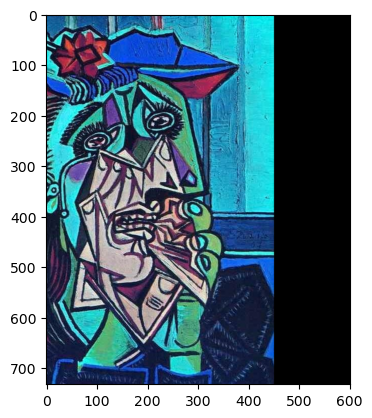

In [22]:
image = cv2.imread('/Users/derrickvanfrausum/Pictures/000000000.jpg')
  
# Store height and width of the image
height, width = image.shape[:2]
  
quarter_height, quarter_width = height / 4, width / 4
  
T = np.float32([[1, 0, -quarter_width], [0, 1, 0]])
  
# We use warpAffine to transform
# the image using the matrix, T
img_translation = cv2.warpAffine(image, T, (width, height))

plt.imshow(img_translation)
plt.show()

In [ ]:
# get current date
today = date.today().strftime("%Y%m%d")

# for hue in np.linspace(20,24, 2, dtype=np.uint8):
# for hue in [33]:
for i in range(1):

    # set input & output video path
    video_path = Path("assets/images/gagu/gagu_for_shadow.mp4")

    # Initialize video stream
    video_cap = cv2.VideoCapture(str(video_path))
    video_cap_2 = cv2.VideoCapture(str(video_path_2))

    # set window names
    # WINDOW_NAME_DIFF = "diff"
    WINDOW_NAME_VIDEO = "video"

    # get video parameters
    video_n_frames = video_cap.get(cv2.CAP_PROP_FRAME_COUNT)
    video_fps = video_cap.get(cv2.CAP_PROP_FPS)
    video_width = int(video_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    video_height = int(video_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"number of frames = {video_n_frames}")
    print(f"fps = {video_fps}")
    print(f"video width = {video_width}")
    print(f"video height = {video_height}")

    # set codec for output video
    codec = "H264"

    # set colormap
    # colormap = cv2.COLORMAP_BONE
    colormap = cv2.COLORMAP_OCEAN
    # colormap = "random_ocean_inferno"
    colormaps = [
        cv2.COLORMAP_OCEAN,
        cv2.COLORMAP_INFERNO,
        # cv2.COLORMAP_DEEPGREEN
        ]

    frames_window = []
    # NB_MASKS = int(0.20*video_fps) # number of masks for 0.5 second int(video_n_frames)
    NB_FRAMES = 3

    rotate = False
    resize = False

    # set output shape
    # out_height, out_width, out_channel = 1920, 1080, 3
    out_height, out_width, out_channel = video_height, video_width*3, 3
    # out_height, out_width, out_channel = video_height, video_width, 3

    # out_path = f"assets/images/bg_remover/{video_path.stem}_{today}_masks_{colormap}_{hue}.mp4"
    out_path = f"assets/images/bg_remover/{video_path.stem}_{today}_translate.mp4"

    # create a videoWriter object
    fourcc = cv2.VideoWriter_fourcc(*codec)
    out_video = cv2.VideoWriter(filename=str(out_path), fourcc=fourcc, fps=video_fps, frameSize=(out_width, out_height))

    # # set frame position to a given index
    # video_cap.set(cv2.CAP_PROP_POS_FRAMES, int(1*video_fps)) # at x seconds

    frame_nb = 0
    translation_nb = 0

    out_frame = np.zeros((out_height, out_width, 3), dtype=np.uint8)
    canvas = np.zeros((video_height, video_width, 3), dtype=np.uint8)

    # while accessing stream 
    while True:

        # read video stream
        ret, frame = video_cap.read()

        if not ret:
            print("Ignoring empty camera frame.")
            break

        frames_window.append(frame)
        if len(frames_window) > NB_FRAMES:
            frames_window = frames_window[1:]

        translation_x = -200

        T = np.float32([[1, 0, translation_x], [0, 1, 0]])
        
        # We use warpAffine to transform
        # the image using the matrix, T
        out_frame = cv2.warpAffine(out_frame, T, (out_width, out_height))
    
        history_frame = out_frame.copy()
            
        frames = cv2.hconcat(frames_window)
        out_frame = cv2.addWeighted(history_frame,0.9, mask, 1, 0)


        # rotate & resize frame if asked
        if rotate:
            out_frame = np.rot90(out_frame, -1)
        
        if resize:
            out_frame = resize_with_crop(out_frame, ref_img_shape=(out_height, out_width, out_channel))

        # write output frame
        out_video.write(out_frame)

        # show to screen
        # cv2.imshow(WINDOW_NAME_DIFF, mask)
        cv2.imshow(WINDOW_NAME_VIDEO, out_frame)

        # wait for a key 
        # 0xFF to check what key we pressed on the keyboard
        key = cv2.waitKey(10) & 0xFF

        # break out of the stream loop if esc is pressed
        if key == 27 or key == ord('q'):        
            break

        frame_nb += 1
        translation_nb += 1


    # quit windows
    cv2.destroyAllWindows()
    cv2.waitKey(1) # workaround to effectively close window on mac

    # release video stream & video rendering
    video_cap.release()
    video_cap_2.release()
    out_video.release()
